In [5]:
import pandas as pd
pd.set_option('display.max_columns', None)  # Show all columns in the DataFrame

# Set Up

In [31]:
TRIAL_1_DATA_PATH = "../Data/CleanData/Trial_1_Mean_Sensor_FW_No_Lag.csv"
TRIAL_2_DATA_PATH = "../Data/CleanData/Trial_2_Mean_Sensor_FW_No_Lag.csv"

def load_trial_1_data(path = TRIAL_1_DATA_PATH):
    df = pd.read_csv(path)
    # add change in fresh weigh variable
    df['fw_change_g'] = df.groupby('plant-id')['total_fresh_weight_g'].diff().fillna(0)
    # drop vairables not in trial 2 and plant-id
    df.drop(columns=['baseline_g', 'volume_flow_rate', 'volume', 'total_fresh_weight_g', 'plant-id'], inplace=True)
    return df

def load_trial_2_data(path = TRIAL_2_DATA_PATH):
    df = pd.read_csv(path)
    df.drop(columns=['plant_id', 'total_fresh_weight_g'], inplace=True)
    return df

def load_combined_data():
    df_1 = load_trial_1_data()
    df_2 = load_trial_2_data()
    combined_df = pd.concat([df_1, df_2], ignore_index=True)
    combined_df.sort_values(by=['day', 'fw_change_g'], inplace=True)
    combined_df = combined_df [ (combined_df['day'] > 0) ].reset_index(drop=True)
    return combined_df

# template for change in fresh weigth variable
# df_mean_sensor_and_lettuce_fw_4days['fw_change_g'] = df_mean_sensor_and_lettuce_fw_4days.groupby('plant_id')['total_fresh_weight_g'].diff().fillna(0) 

In [32]:
df = load_combined_data()
df

,day,carbon_dioxide,temp_env,humidity,pressure,electrical_conductivity,temp_nutr,fw_change_g
0,4.0,487.000000,22.425714,62.214082,99060.374490,1361.010204,23.987102,4.0
1,4.0,487.000000,22.425714,62.214082,99060.374490,1361.010204,23.987102,6.2
2,4.0,487.000000,22.425714,62.214082,99060.374490,1361.010204,23.987102,6.7
3,4.0,487.000000,22.425714,62.214082,99060.374490,1361.010204,23.987102,7.3
4,4.0,487.000000,22.425714,62.214082,99060.374490,1361.010204,23.987102,8.3
...,...,...,...,...,...,...,...,...
135,28.0,511.530612,22.304286,71.859592,99342.587347,1943.295918,26.928286,77.0
136,28.0,511.530612,22.304286,71.859592,99342.587347,1943.295918,26.928286,78.0
137,28.0,511.530612,22.304286,71.859592,99342.587347,1943.295918,26.928286,79.0
138,28.0,511.530612,22.304286,71.859592,99342.587347,1943.295918,26.928286,80.0


In [22]:
df_1

,day,carbon_dioxide,temp_env,humidity,pressure,electrical_conductivity,temp_nutr,fw_change_g
0,0.0,461.250000,22.528333,62.394167,98838.439167,1300.625000,23.835208,0.0
1,0.0,461.250000,22.528333,62.394167,98838.439167,1300.625000,23.835208,0.0
2,0.0,461.250000,22.528333,62.394167,98838.439167,1300.625000,23.835208,0.0
3,0.0,461.250000,22.528333,62.394167,98838.439167,1300.625000,23.835208,0.0
4,0.0,461.250000,22.528333,62.394167,98838.439167,1300.625000,23.835208,0.0
...,...,...,...,...,...,...,...,...
75,28.0,511.530612,22.304286,71.859592,99342.587347,1943.295918,26.928286,79.0
76,28.0,511.530612,22.304286,71.859592,99342.587347,1943.295918,26.928286,80.0
77,28.0,511.530612,22.304286,71.859592,99342.587347,1943.295918,26.928286,70.0
78,28.0,511.530612,22.304286,71.859592,99342.587347,1943.295918,26.928286,64.0


In [23]:
df_2

,day,fw_change_g,carbon_dioxide,electrical_conductivity,temp_env,temp_nutr,humidity,pressure
0,0.0,0.0,0.323495,1437.553398,20.285433,22.909825,83.790346,795.159839
1,0.0,0.0,0.323495,1437.553398,20.285433,22.909825,83.790346,795.159839
2,0.0,0.0,0.323495,1437.553398,20.285433,22.909825,83.790346,795.159839
3,0.0,0.0,0.323495,1437.553398,20.285433,22.909825,83.790346,795.159839
4,0.0,0.0,0.323495,1437.553398,20.285433,22.909825,83.790346,795.159839
...,...,...,...,...,...,...,...,...
75,28.0,66.0,546.282779,1446.892368,21.491528,21.611981,77.851267,621.142045
76,28.0,53.0,546.282779,1446.892368,21.491528,21.611981,77.851267,621.142045
77,28.0,57.0,546.282779,1446.892368,21.491528,21.611981,77.851267,621.142045
78,28.0,71.0,546.282779,1446.892368,21.491528,21.611981,77.851267,621.142045


# Neural Network 1

Fold [1/5], Final Val Loss (MSE): 46.8886, Final Val RMSE: 6.8475


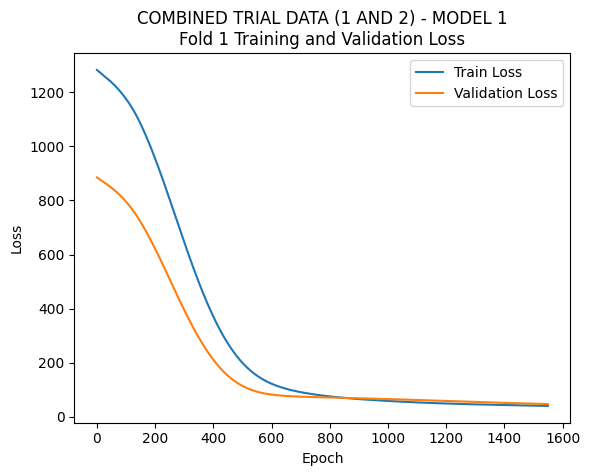

Fold [2/5], Final Val Loss (MSE): 49.2070, Final Val RMSE: 7.0148


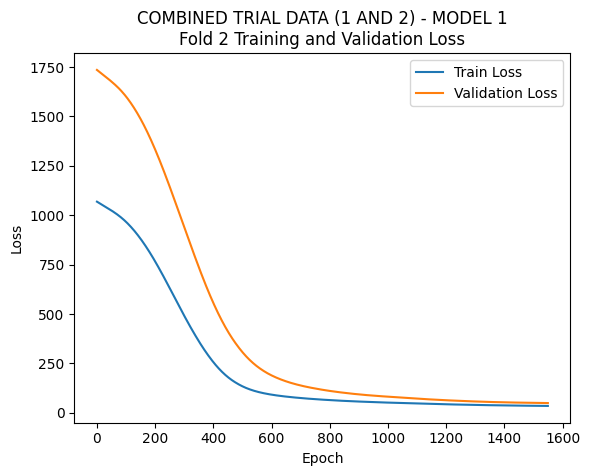

Fold [3/5], Final Val Loss (MSE): 61.6444, Final Val RMSE: 7.8514


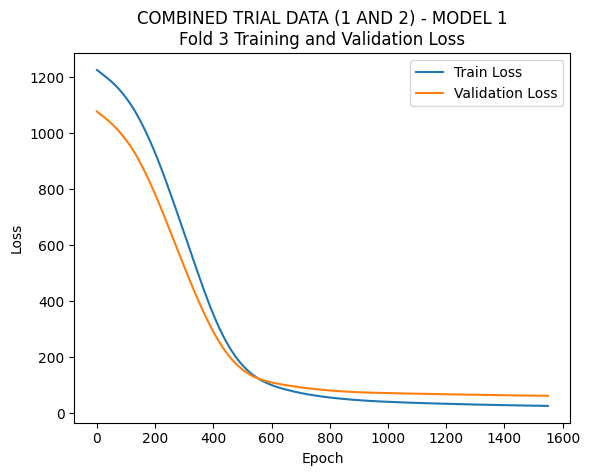

Fold [4/5], Final Val Loss (MSE): 24.0784, Final Val RMSE: 4.9070


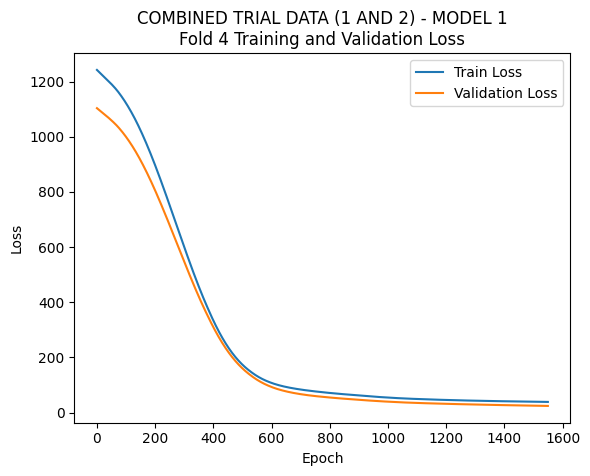

Fold [5/5], Final Val Loss (MSE): 41.9812, Final Val RMSE: 6.4793


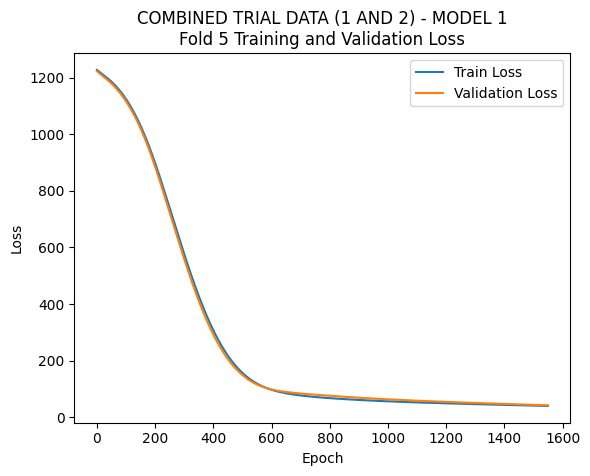


Mean CV Val Loss (MSE): 44.7599
Mean CV Val Loss (RMSE): 6.6903
Std CV Val Loss (MSE): 12.2052
Std CV Val Loss (RMSE): 3.4936


In [45]:

# load data 

import torch
import numpy as np


df = load_combined_data()

target_col = 'fw_change_g'

X = df.drop(columns=[target_col]).to_numpy(dtype=np.float32)
y = df[target_col].to_numpy(dtype=np.float32)

feature_names = df.drop(columns=[target_col]).columns.tolist()

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


#### Neural Network Model
class BasicNN(nn.Module): # inherits from Module
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__() # call initialization from module
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)

        return x
    
# pick manual seed
torch.manual_seed(42)

# hyperparameters    
input_size = X_train.shape[1]
hidden_size = 32
output_size = 1
learning_rate = .001
num_epochs = 1550

# loss function
criterion = nn.MSELoss()

# cross validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_val_losses = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
    
    X_train_fold = X_train[train_idx]
    y_train_fold = y_train[train_idx]
    X_val_fold = X_train[val_idx]
    y_val_fold = y_train[val_idx]
    
    # standardize within each fold
    scaler = StandardScaler()
    X_train_fold = scaler.fit_transform(X_train_fold).astype(np.float32)
    X_val_fold = scaler.transform(X_val_fold).astype(np.float32)
    
    # convert to tensors
    X_train_tensor = torch.tensor(X_train_fold, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train_fold, dtype=torch.float32).view(-1, 1)
    X_val_tensor = torch.tensor(X_val_fold, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val_fold, dtype=torch.float32).view(-1, 1)
    
    # initialize model
    model = BasicNN(input_size=input_size, hidden_size=hidden_size, output_size=output_size)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    # train
    train_losses = []
    val_losses = []
    
    for epoch in range(num_epochs):
        model.train()
        outputs = model(X_train_tensor) # get predicted results
        loss = criterion(outputs, y_train_tensor) 
        optimizer.zero_grad() 
        loss.backward() # compute gradients
        optimizer.step() # update weights
        
        train_losses.append(loss.item())
        
        # validation
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val_tensor)
            val_loss = criterion(val_outputs, y_val_tensor)
        
        val_losses.append(val_loss.item())
    
    cv_val_losses.append(val_losses[-1])
    
    print(f"Fold [{fold+1}/5], Final Val Loss (MSE): {val_losses[-1]:.4f}, Final Val RMSE: {np.sqrt(val_losses[-1]):.4f}")
    
    plt.figure()
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"COMBINED TRIAL DATA (1 AND 2) - MODEL 1\nFold {fold+1} Training and Validation Loss")
    plt.legend()
    plt.savefig(f'../Figures/COMBINED_TRIAL_1_2_DATA_MODEL_1_fold_{fold+1}_training_validation_loss.png')
    plt.show()

print(f"\nMean CV Val Loss (MSE): {np.mean(cv_val_losses):.4f}")
print(f"Mean CV Val Loss (RMSE): {np.sqrt(np.mean(cv_val_losses)):.4f}")
print(f"Std CV Val Loss (MSE): {np.std(cv_val_losses):.4f}")
print(f"Std CV Val Loss (RMSE): {np.sqrt(np.std(cv_val_losses)):.4f}")


Epoch [1/1550], Train Loss: 1202.1559
Epoch [2/1550], Train Loss: 1201.2794
Epoch [3/1550], Train Loss: 1200.4047
Epoch [4/1550], Train Loss: 1199.5322
Epoch [5/1550], Train Loss: 1198.6591
Epoch [6/1550], Train Loss: 1197.7867
Epoch [7/1550], Train Loss: 1196.9158
Epoch [8/1550], Train Loss: 1196.0461
Epoch [9/1550], Train Loss: 1195.1832
Epoch [10/1550], Train Loss: 1194.3309
Epoch [11/1550], Train Loss: 1193.4783
Epoch [12/1550], Train Loss: 1192.6289
Epoch [13/1550], Train Loss: 1191.7793
Epoch [14/1550], Train Loss: 1190.9285
Epoch [15/1550], Train Loss: 1190.0765
Epoch [16/1550], Train Loss: 1189.2253
Epoch [17/1550], Train Loss: 1188.3737
Epoch [18/1550], Train Loss: 1187.5248
Epoch [19/1550], Train Loss: 1186.6748
Epoch [20/1550], Train Loss: 1185.8217
Epoch [21/1550], Train Loss: 1184.9670
Epoch [22/1550], Train Loss: 1184.1106
Epoch [23/1550], Train Loss: 1183.2526
Epoch [24/1550], Train Loss: 1182.3929
Epoch [25/1550], Train Loss: 1181.5323
Epoch [26/1550], Train Loss: 1180.

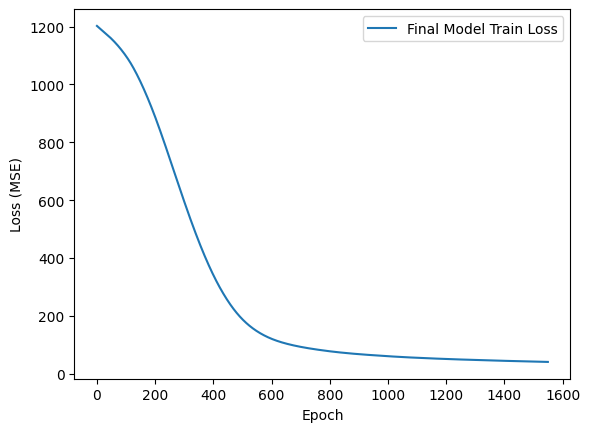

In [46]:
# train final model on full training set

# hyperparameters    
input_size = X_train.shape[1]
hidden_size = 32
output_size = 1
learning_rate = .001
num_epochs = 1550

# standardize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_test = scaler.transform(X_test).astype(np.float32)

# convert to tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

# initialize model
torch.manual_seed(42)
model1 = BasicNN(input_size=input_size, hidden_size=hidden_size, output_size=output_size)
optimizer = optim.Adam(model1.parameters(), lr=learning_rate)

# train final model and store training loss
train_losses = []

for epoch in range(num_epochs):
    model1.train()
    outputs = model1(X_train_tensor) # get predicted results
    loss = criterion(outputs, y_train_tensor) 
    optimizer.zero_grad() 
    loss.backward() # compute gradients
    optimizer.step() # update weights

    train_losses.append(loss.item())

    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {loss.item():.4f}")

# final test evaluation
model1.eval()
with torch.no_grad():
    test_outputs = model1(X_test_tensor)
    test_loss = criterion(test_outputs, y_test_tensor)

print(f"\nFinal Test Loss (MSE): {test_loss.item():.4f}")
print(f"Final Test Loss (RMSE): {np.sqrt(test_loss.item()):.4f}")

plt.plot(train_losses, label="Final Model Train Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.savefig('../Figures/COMBINED_TRIAL_1_2_DATA_MODEL_1_final_training_loss.png')
plt.show()

## Permutation Importance


Baseline RMSE: 6.158334

Permutation results (20-repeat average):
day                        RMSE=19.5362  (Δ=+13.3779,  sd=1.7133)
electrical_conductivity    RMSE=15.9662  (Δ=+9.8078,  sd=1.7317)
temp_nutr                  RMSE=9.7784  (Δ=+3.6200,  sd=0.8890)
humidity                   RMSE=9.6936  (Δ=+3.5352,  sd=0.8459)
temp_env                   RMSE=8.7748  (Δ=+2.6165,  sd=0.9847)
pressure                   RMSE=8.6095  (Δ=+2.4511,  sd=0.8320)
carbon_dioxide             RMSE=6.5061  (Δ=+0.3478,  sd=0.3207)


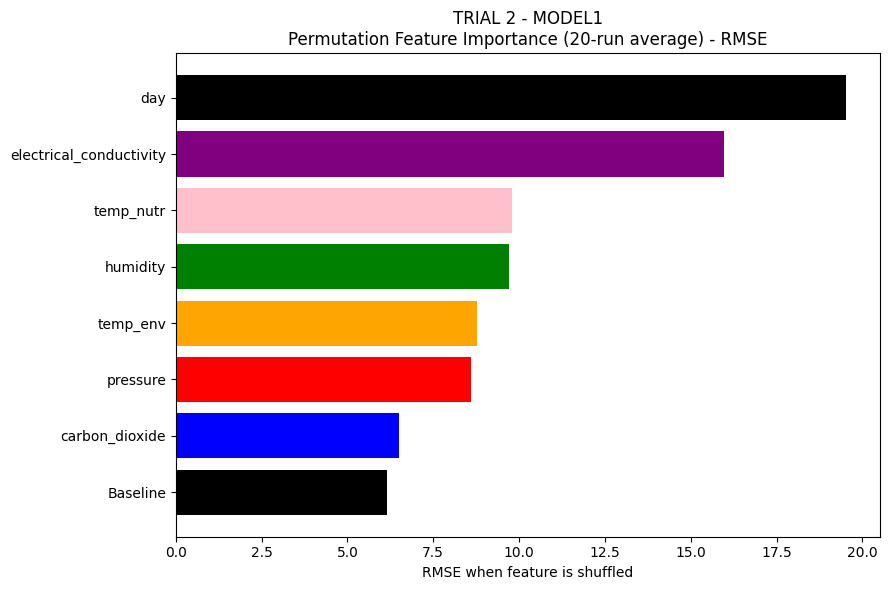

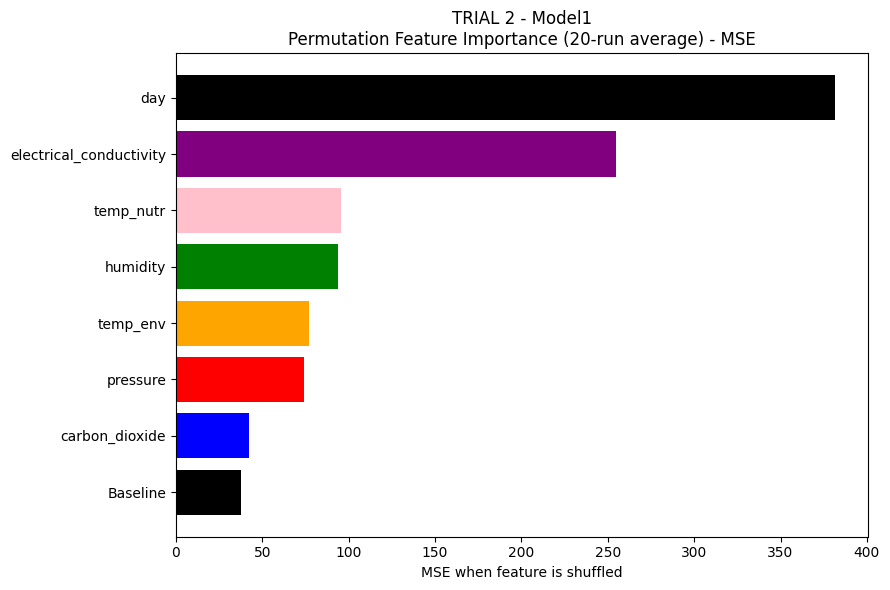

In [47]:
import numpy as np
import torch
import random
import matplotlib.pyplot as plt

# ==============================
# RMSE function
# ==============================
def rmse(y_pred, y_true):
    return np.sqrt(np.mean((y_pred - y_true) ** 2))

model1.eval()

# ==============================
# Baseline RMSE
# ==============================
with torch.no_grad():
    base_preds = model1(X_test_tensor).cpu().numpy()

y_true = y_test_tensor.cpu().numpy()
base_rmse = rmse(base_preds, y_true)

# ==============================
# Permutation Importance (20 repeats)
# ==============================
repeats = 20
perm_results = []
torch.manual_seed(42)

X_test_base = X_test_tensor.clone()
N = X_test_base.shape[0]

for j, name in enumerate(feature_names):
    rmses = []

    for r in range(repeats):
        X_perm = X_test_base.clone()

        # shuffle feature j
        idx = torch.randperm(N)
        X_perm[:, j] = X_perm[idx, j]

        with torch.no_grad():
            preds = model1(X_perm).cpu().numpy()

        rmses.append(rmse(preds, y_true))

    avg_perm_rmse = np.mean(rmses)
    std_perm_rmse = np.std(rmses)

    perm_results.append((name, avg_perm_rmse, std_perm_rmse))

# Sort by average permuted RMSE (largest first)
perm_results.sort(key=lambda x: x[1], reverse=True)

# ==============================
# Print results
# ==============================
print("Baseline RMSE:", round(base_rmse, 6))
print("\nPermutation results (20-repeat average):")

for name, avg_rmse, std_rmse in perm_results:
    delta = avg_rmse - base_rmse
    print(f"{name:25s}  RMSE={avg_rmse:.4f}  (Δ={delta:+.4f},  sd={std_rmse:.4f})")

# ==============================
# Plot
# ==============================

coef_colors = {
    'carbon_dioxide': 'blue',
    'temp_env': 'orange',
    'humidity': 'green',
    'pressure': 'red',
    'electrical_conductivity': 'purple',
    'volume': 'brown',
    'temp_nutr': 'pink',
    'volume_flow_rate': 'gray',
    'weight_lag_1': 'cyan',
    'weight_lag_2': 'magenta'
}

baseline_color = "black"

names = [n for n, _, _ in perm_results]
rmses = [r for _, r, _ in perm_results]
colors = [coef_colors.get(name, 'black') for name in names]

# Add baseline as separate bar
names_plot = names + ["Baseline"]
rmses_plot = rmses + [base_rmse]
colors_plot = colors + [baseline_color]

plt.figure(figsize=(9, 6))
plt.barh(names_plot[::-1], rmses_plot[::-1], color=colors_plot[::-1])

plt.xlabel("RMSE when feature is shuffled")
plt.title("TRIAL 2 - MODEL1\nPermutation Feature Importance (20-run average) - RMSE")
plt.tight_layout()

plt.savefig('../Figures/t2_nn_model1_permutation_importance_rmse.png', bbox_inches='tight')
plt.show()

# plot for mse instead of rmse
plt.figure(figsize=(9, 6))
plt.barh(names_plot[::-1], [r**2 for r in rmses_plot][::-1], color=colors_plot[::-1])
plt.xlabel("MSE when feature is shuffled")
plt.title("TRIAL 2 - Model1\nPermutation Feature Importance (20-run average) - MSE")
plt.tight_layout()
plt.savefig('../Figures/nnmodel1_permutation_importance_mse.png', bbox_inches='tight')
plt.show()

# Neural Network 2
Dropping Day Feature

Fold [1/5], Final Val Loss (MSE): 28.7147, Final Val RMSE: 5.3586


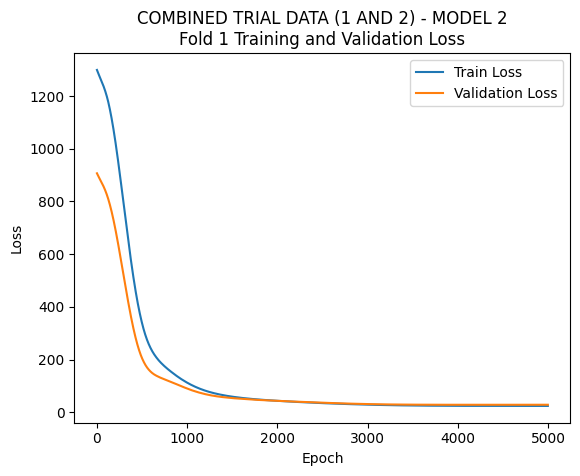

Fold [2/5], Final Val Loss (MSE): 30.1629, Final Val RMSE: 5.4921


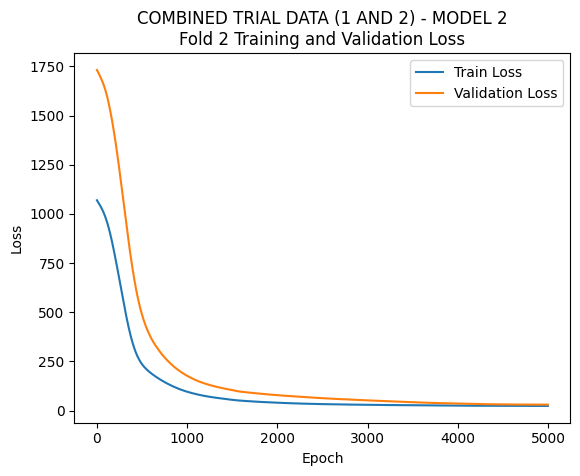

Fold [3/5], Final Val Loss (MSE): 53.6867, Final Val RMSE: 7.3271


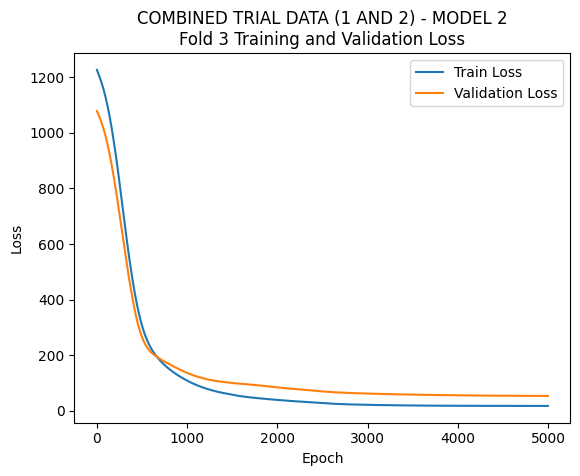

Fold [4/5], Final Val Loss (MSE): 9.8186, Final Val RMSE: 3.1335


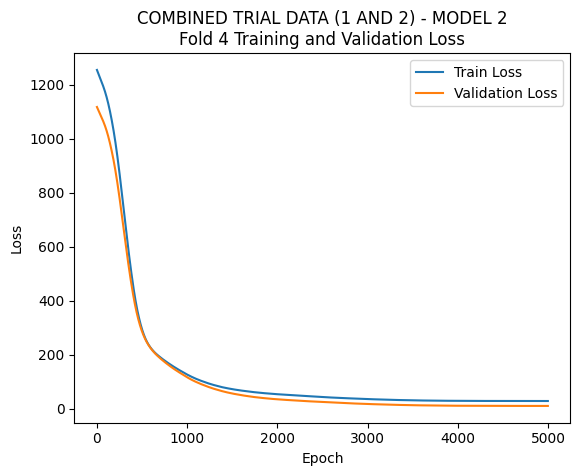

Fold [5/5], Final Val Loss (MSE): 21.6950, Final Val RMSE: 4.6578


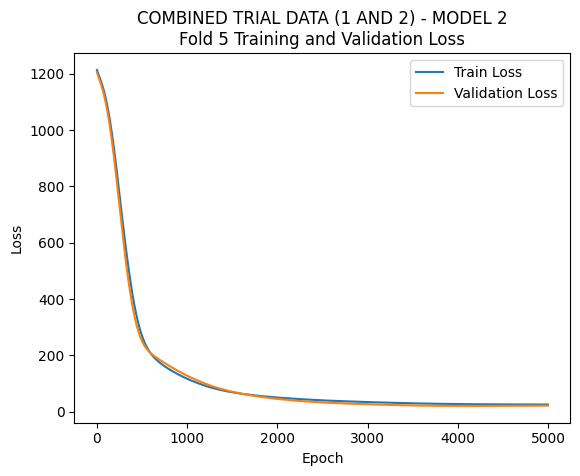


Mean CV Val Loss (MSE): 28.8156
Mean CV Val Loss (RMSE): 5.3680
Std CV Val Loss (MSE): 14.3665
Std CV Val Loss (RMSE): 3.7903


In [58]:

# load data 

import torch
import numpy as np


df = load_combined_data()
df = df.drop(columns=['day']) # drop day feature for model 2

target_col = 'fw_change_g'

X = df.drop(columns=[target_col]).to_numpy(dtype=np.float32)
y = df[target_col].to_numpy(dtype=np.float32)

feature_names = df.drop(columns=[target_col]).columns.tolist()

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


#### Neural Network Model
class BasicNN(nn.Module): # inherits from Module
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__() # call initialization from module
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)

        return x
    
# pick manual seed
torch.manual_seed(42)

# hyperparameters    
input_size = X_train.shape[1]
hidden_size = 32
output_size = 1
learning_rate = .001
num_epochs = 5000

# loss function
criterion = nn.MSELoss()

# cross validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_val_losses = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
    
    X_train_fold = X_train[train_idx]
    y_train_fold = y_train[train_idx]
    X_val_fold = X_train[val_idx]
    y_val_fold = y_train[val_idx]
    
    # standardize within each fold
    scaler = StandardScaler()
    X_train_fold = scaler.fit_transform(X_train_fold).astype(np.float32)
    X_val_fold = scaler.transform(X_val_fold).astype(np.float32)
    
    # convert to tensors
    X_train_tensor = torch.tensor(X_train_fold, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train_fold, dtype=torch.float32).view(-1, 1)
    X_val_tensor = torch.tensor(X_val_fold, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val_fold, dtype=torch.float32).view(-1, 1)
    
    # initialize model
    model = BasicNN(input_size=input_size, hidden_size=hidden_size, output_size=output_size)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    # train
    train_losses = []
    val_losses = []
    
    for epoch in range(num_epochs):
        model.train()
        outputs = model(X_train_tensor) # get predicted results
        loss = criterion(outputs, y_train_tensor) 
        optimizer.zero_grad() 
        loss.backward() # compute gradients
        optimizer.step() # update weights
        
        train_losses.append(loss.item())
        
        # validation
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val_tensor)
            val_loss = criterion(val_outputs, y_val_tensor)
        
        val_losses.append(val_loss.item())
    
    cv_val_losses.append(val_losses[-1])
    
    print(f"Fold [{fold+1}/5], Final Val Loss (MSE): {val_losses[-1]:.4f}, Final Val RMSE: {np.sqrt(val_losses[-1]):.4f}")
    
    plt.figure()
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"COMBINED TRIAL DATA (1 AND 2) - MODEL 2\nFold {fold+1} Training and Validation Loss")
    plt.legend()
    plt.savefig(f'../Figures/COMBINED_TRIAL_1_2_DATA_MODEL_2_fold_{fold+1}_training_validation_loss.png')
    plt.show()

print(f"\nMean CV Val Loss (MSE): {np.mean(cv_val_losses):.4f}")
print(f"Mean CV Val Loss (RMSE): {np.sqrt(np.mean(cv_val_losses)):.4f}")
print(f"Std CV Val Loss (MSE): {np.std(cv_val_losses):.4f}")
print(f"Std CV Val Loss (RMSE): {np.sqrt(np.std(cv_val_losses)):.4f}")


Epoch [1/1550], Train Loss: 1218.2428
Epoch [2/1550], Train Loss: 1217.3561
Epoch [3/1550], Train Loss: 1216.4724
Epoch [4/1550], Train Loss: 1215.5918
Epoch [5/1550], Train Loss: 1214.7142
Epoch [6/1550], Train Loss: 1213.8397
Epoch [7/1550], Train Loss: 1212.9749
Epoch [8/1550], Train Loss: 1212.1152
Epoch [9/1550], Train Loss: 1211.2631
Epoch [10/1550], Train Loss: 1210.4143
Epoch [11/1550], Train Loss: 1209.5676
Epoch [12/1550], Train Loss: 1208.7230
Epoch [13/1550], Train Loss: 1207.8820
Epoch [14/1550], Train Loss: 1207.0488
Epoch [15/1550], Train Loss: 1206.2181
Epoch [16/1550], Train Loss: 1205.3907
Epoch [17/1550], Train Loss: 1204.5660
Epoch [18/1550], Train Loss: 1203.7434
Epoch [19/1550], Train Loss: 1202.9236
Epoch [20/1550], Train Loss: 1202.1107
Epoch [21/1550], Train Loss: 1201.3036
Epoch [22/1550], Train Loss: 1200.5020
Epoch [23/1550], Train Loss: 1199.7031
Epoch [24/1550], Train Loss: 1198.9071
Epoch [25/1550], Train Loss: 1198.1144
Epoch [26/1550], Train Loss: 1197.

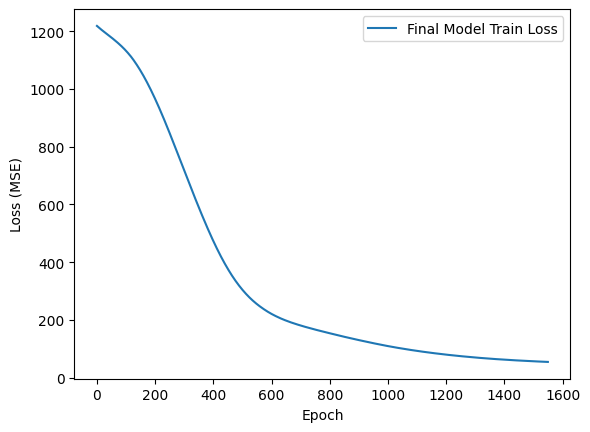

In [59]:
# train final model on full training set

# hyperparameters    
input_size = X_train.shape[1]
hidden_size = 32
output_size = 1
learning_rate = .001
num_epochs = 1550

# standardize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_test = scaler.transform(X_test).astype(np.float32)

# convert to tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

# initialize model
torch.manual_seed(42)
model2 = BasicNN(input_size=input_size, hidden_size=hidden_size, output_size=output_size)
optimizer = optim.Adam(model2.parameters(), lr=learning_rate)

# train final model and store training loss
train_losses = []

for epoch in range(num_epochs):
    model2.train()
    outputs = model2(X_train_tensor) # get predicted results
    loss = criterion(outputs, y_train_tensor) 
    optimizer.zero_grad() 
    loss.backward() # compute gradients
    optimizer.step() # update weights

    train_losses.append(loss.item())

    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {loss.item():.4f}")

# final test evaluation
model2.eval()
with torch.no_grad():
    test_outputs = model2(X_test_tensor)
    test_loss = criterion(test_outputs, y_test_tensor)

print(f"\nFinal Test Loss (MSE): {test_loss.item():.4f}")
print(f"Final Test Loss (RMSE): {np.sqrt(test_loss.item()):.4f}")

plt.plot(train_losses, label="Final Model Train Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.savefig('../Figures/COMBINED_TRIAL_1_2_DATA_MODEL_2_final_training_loss.png')
plt.show()

Baseline RMSE: 7.572384

Permutation results (20-repeat average):
electrical_conductivity    RMSE=32.3405  (Δ=+24.7681,  sd=3.4409)
temp_nutr                  RMSE=17.4763  (Δ=+9.9039,  sd=2.2172)
humidity                   RMSE=15.3412  (Δ=+7.7688,  sd=1.1689)
temp_env                   RMSE=10.8336  (Δ=+3.2612,  sd=1.0453)
pressure                   RMSE=10.5640  (Δ=+2.9916,  sd=1.6810)
carbon_dioxide             RMSE=7.8046  (Δ=+0.2322,  sd=0.1485)


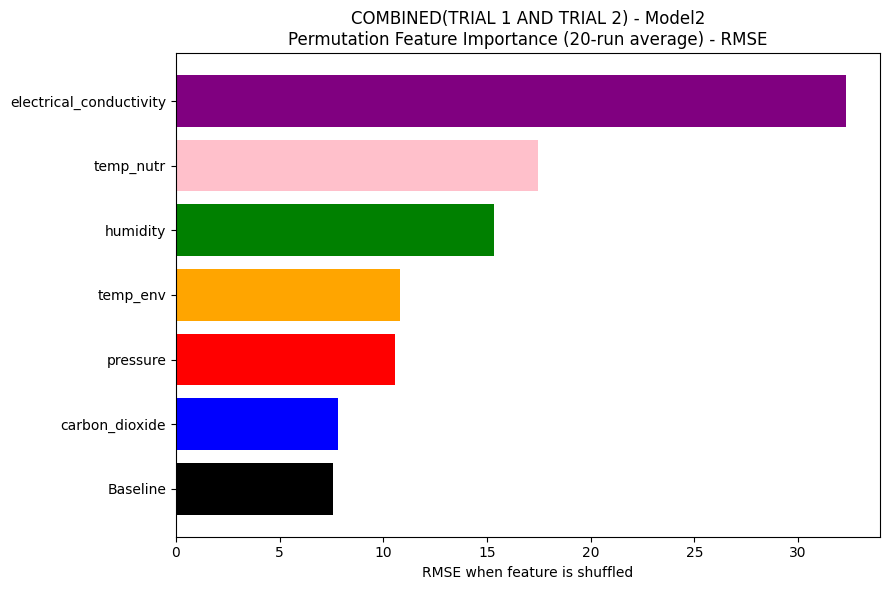

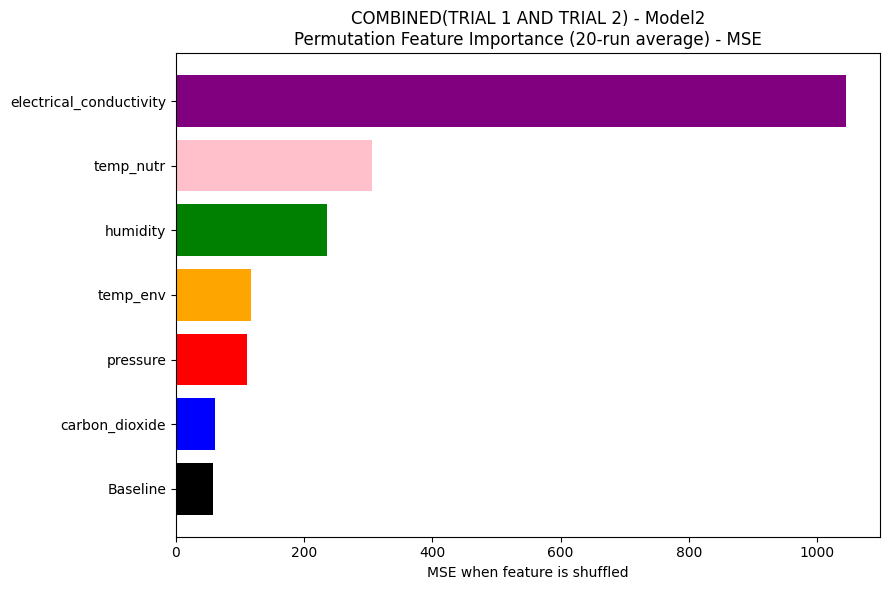

In [66]:
import numpy as np
import torch
import random
import matplotlib.pyplot as plt

# ==============================
# RMSE function
# ==============================
def rmse(y_pred, y_true):
    return np.sqrt(np.mean((y_pred - y_true) ** 2))

model2.eval()

# ==============================
# Baseline RMSE
# ==============================
with torch.no_grad():
    base_preds = model2(X_test_tensor).cpu().numpy()

y_true = y_test_tensor.cpu().numpy()
base_rmse = rmse(base_preds, y_true)

# ==============================
# Permutation Importance (20 repeats)
# ==============================
repeats = 20
perm_results = []
torch.manual_seed(42)

X_test_base = X_test_tensor.clone()
N = X_test_base.shape[0]

for j, name in enumerate(feature_names):
    rmses = []

    for r in range(repeats):
        X_perm = X_test_base.clone()

        # shuffle feature j
        idx = torch.randperm(N)
        X_perm[:, j] = X_perm[idx, j]

        with torch.no_grad():
            preds = model2(X_perm).cpu().numpy()

        rmses.append(rmse(preds, y_true))

    avg_perm_rmse = np.mean(rmses)
    std_perm_rmse = np.std(rmses)

    perm_results.append((name, avg_perm_rmse, std_perm_rmse))

# Sort by average permuted RMSE (largest first)
perm_results.sort(key=lambda x: x[1], reverse=True)

# ==============================
# Print results
# ==============================
print("Baseline RMSE:", round(base_rmse, 6))
print("\nPermutation results (20-repeat average):")

for name, avg_rmse, std_rmse in perm_results:
    delta = avg_rmse - base_rmse
    print(f"{name:25s}  RMSE={avg_rmse:.4f}  (Δ={delta:+.4f},  sd={std_rmse:.4f})")

# ==============================
# Plot
# ==============================

coef_colors = {
    'carbon_dioxide': 'blue',
    'temp_env': 'orange',
    'humidity': 'green',
    'pressure': 'red',
    'electrical_conductivity': 'purple',
    'volume': 'brown',
    'temp_nutr': 'pink',
    'volume_flow_rate': 'gray',
    'weight_lag_1': 'cyan',
    'weight_lag_2': 'magenta'
}

baseline_color = "black"

names = [n for n, _, _ in perm_results]
rmses = [r for _, r, _ in perm_results]
colors = [coef_colors.get(name, 'black') for name in names]

# Add baseline as separate bar
names_plot = names + ["Baseline"]
rmses_plot = rmses + [base_rmse]
colors_plot = colors + [baseline_color]

plt.figure(figsize=(9, 6))
plt.barh(names_plot[::-1], rmses_plot[::-1], color=colors_plot[::-1])

plt.xlabel("RMSE when feature is shuffled")
plt.title("COMBINED(TRIAL 1 AND TRIAL 2) - Model2\nPermutation Feature Importance (20-run average) - RMSE")
plt.tight_layout()

plt.savefig('../Figures/combined_nnmodel2_permutation_importance_rmse.png', bbox_inches='tight')
plt.show()

# plot for mse instead of rmse
plt.figure(figsize=(9, 6))
plt.barh(names_plot[::-1], [r**2 for r in rmses_plot][::-1], color=colors_plot[::-1])
plt.xlabel("MSE when feature is shuffled")
plt.title("COMBINED(TRIAL 1 AND TRIAL 2) - Model2\nPermutation Feature Importance (20-run average) - MSE")
plt.tight_layout()
plt.savefig('../Figures/combined_nnmodel2_permutation_importance_mse.png', bbox_inches='tight')
plt.show()

## Partial Dependence Plots

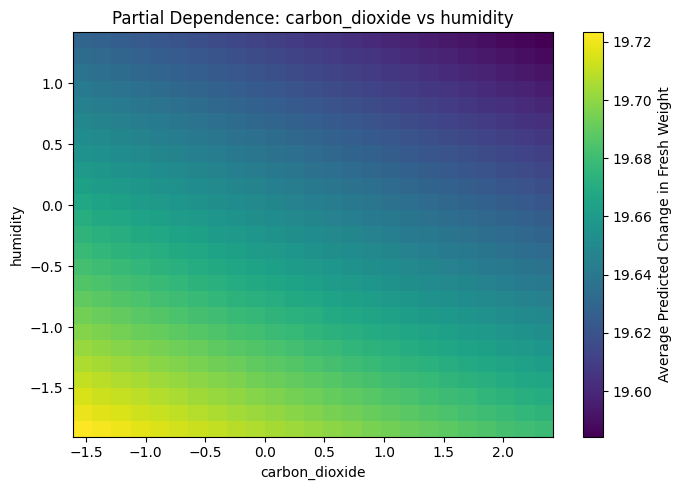

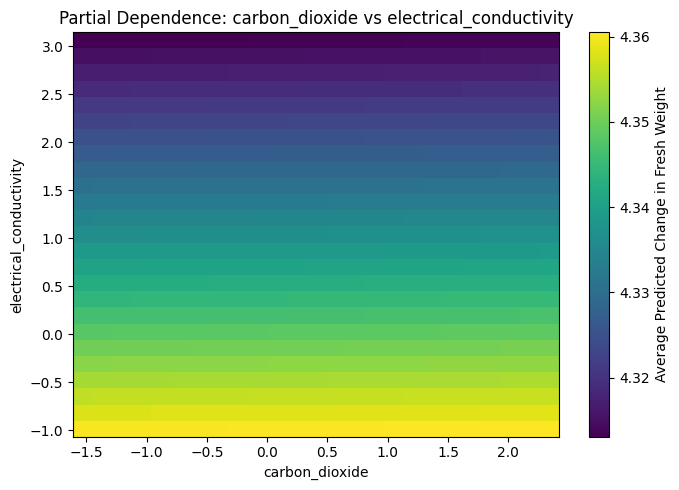

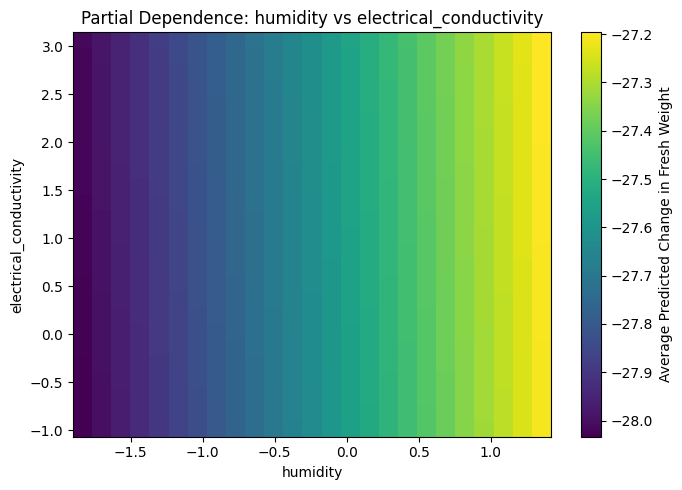

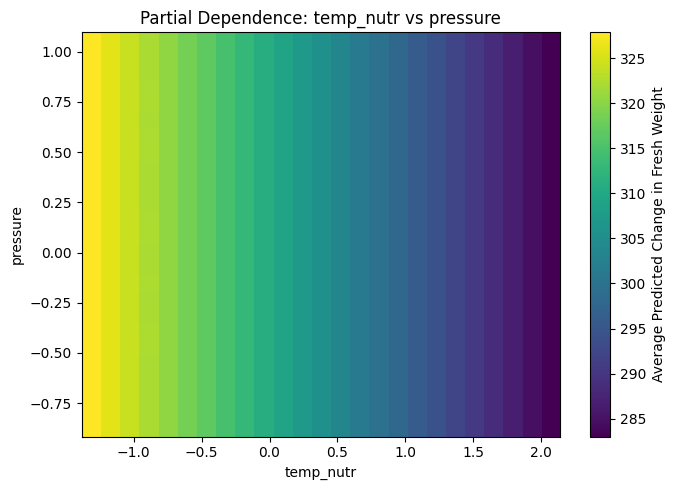

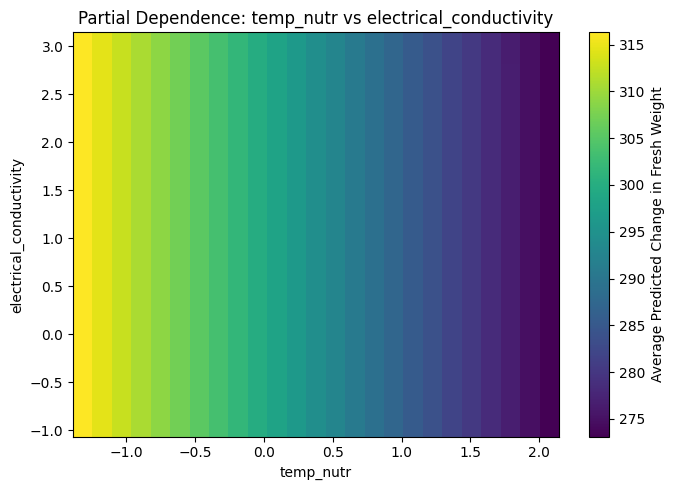

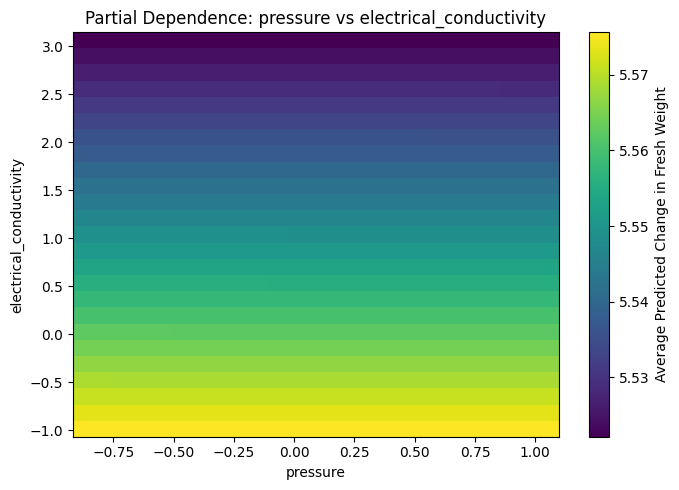

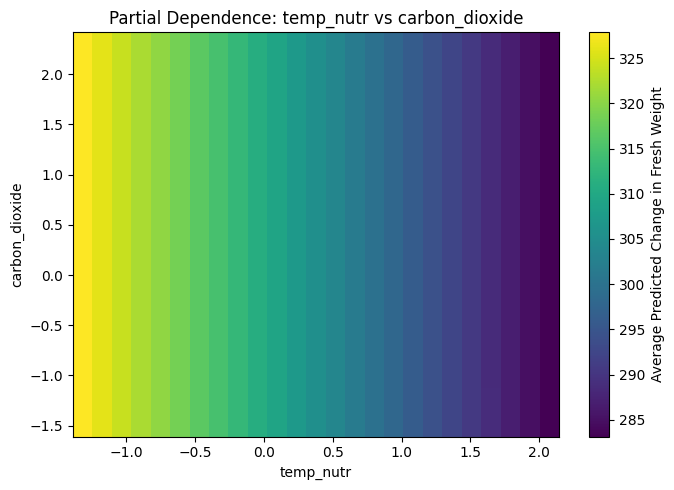

In [63]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# make sure model is in eval mode
model2.eval()

# feature pairs to examine
feature_pairs = [
    ("carbon_dioxide", "humidity"),
    ("carbon_dioxide", "electrical_conductivity"),
    ("humidity", "electrical_conductivity"),
    ("temp_nutr", "pressure"),
    ("temp_nutr", "electrical_conductivity"),
    ("pressure", "electrical_conductivity"),
    ("temp_nutr", "carbon_dioxide"),
]

# map feature names to column indices
name_to_idx = {name: i for i, name in enumerate(feature_names)}

# use the ORIGINAL unscaled training data to define realistic value ranges
# and use the SCALED test tensor as the base data that gets modified
X_reference = X_test_tensor.clone()

grid_size = 25

for feat1, feat2 in feature_pairs:
    idx1 = name_to_idx[feat1]
    idx2 = name_to_idx[feat2]
    
    # grid in original feature units
    vals1_raw = np.linspace(X_train[:, idx1].min(), X_train[:, idx1].max(), grid_size)
    vals2_raw = np.linspace(X_train[:, idx2].min(), X_train[:, idx2].max(), grid_size)
    
    pdp = np.zeros((grid_size, grid_size))
    
    for i, v1_raw in enumerate(vals1_raw):
        for j, v2_raw in enumerate(vals2_raw):
            X_temp = X_reference.clone()
            
            # standardize using the fitted scaler from final model training
            v1_scaled = (v1_raw - scaler.mean_[idx1]) / scaler.scale_[idx1]
            v2_scaled = (v2_raw - scaler.mean_[idx2]) / scaler.scale_[idx2]
            
            X_temp[:, idx1] = v1_scaled
            X_temp[:, idx2] = v2_scaled
            
            with torch.no_grad():
                preds = model2(X_temp).cpu().numpy()
            
            pdp[j, i] = preds.mean()
    
    plt.figure(figsize=(7, 5))
    plt.imshow(
        pdp,
        origin="lower",
        aspect="auto",
        extent=[vals1_raw.min(), vals1_raw.max(), vals2_raw.min(), vals2_raw.max()]
    )
    plt.colorbar(label="Average Predicted Change in Fresh Weight")
    plt.xlabel(feat1)
    plt.ylabel(feat2)
    plt.title(f"Partial Dependence: {feat1} vs {feat2}")
    plt.tight_layout()
    plt.savefig(f"../Figures/tcombined_m2_pdp_{feat1}_{feat2}.png", bbox_inches="tight")
    plt.show()